# LOSO Classical ML Training
Leave-One-Session-Out cross-validation across classical ML classifiers and feature extractors.
Each fold holds out one entire recording session as the validation set.
Grid: 6 extractors × 10 classifiers = 60 combinations per fold.

In [ ]:
import os
import sys
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report

_cwd = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'ml_model' else _cwd
sys.path.insert(0, REPO_ROOT)
from processing.preprocess_pipeline import (
    MNEPipeline, notch, bandpass, rereference, add_idle_class, epoch,
    epoch_filter, extract_tensor, extract_raw, extract_pca, extract_bandpower, extract_csp
)

print(f'REPO_ROOT: {REPO_ROOT}')


ModuleNotFoundError: No module named 'processing'

In [ ]:
# =============================================================================
# Configuration
# =============================================================================

N_CHANNELS   = 8
N_CLASSES    = 2
SFREQ        = 300
TRIAL_DUR    = 3.0
N_TIMEPOINTS = int(SFREQ * TRIAL_DUR) + 1  # 901 — MNE tmax inclusive

# True  → filter each epoch individually (matches per-epoch DL training)
# False → filter the whole file before epoching
PER_EPOCH = True

LABEL_MAP = {'idle': 0, 'move': 0, 'jaw_clench': 1}
MAP_LABEL = {v: k for k, v in LABEL_MAP.items()}

# Derived from LABEL_MAP — used to namespace saved models so runs don't overwrite each other
TARGET = '+'.join(sorted(k for k, v in LABEL_MAP.items() if v == 1))

# Bandpass configs to try — classical models can sweep this cheaply
BANDPASS_CONFIGS = {
    'alpha'          : [(8, 13)],
    'beta'           : [(13, 30)],
    'alpha+beta'     : [(8, 13), (13, 30)],
    'theta+alpha+beta': [(4, 8), (8, 13), (13, 30)],
}

DATA_DIR = os.path.join(REPO_ROOT, 'data_collection', 'annotated_eeg')

FILES = [
    os.path.join(DATA_DIR, 'chengyi_4_8_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_8_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_2.fif'),
]

SAVE_DIR = os.path.join(REPO_ROOT, 'ml_model', 'loso_classical_models', TARGET,
                        'per_epoch' if PER_EPOCH else 'whole_file')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Target      : {TARGET}')
print(f'REPO_ROOT   : {REPO_ROOT}')
print(f'N_TIMEPOINTS: {N_TIMEPOINTS}')
print(f'Files       : {len(FILES)}')


In [ ]:
# =============================================================================
# Classifier registry
# Trimmed to the 8 that performed well in the previous run.
# =============================================================================

CLASSIFIERS = {
    # 'LDA+shrinkage': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    # ]),
    # 'LogReg': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', LogisticRegression(max_iter=1000, C=1.0)),
    # ]),
    'SVM_linear': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', C=1.0, probability=True)),
    ]),
    # 'RandomForest': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    # ]),
    # 'ExtraTrees': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    # ]),
    # 'GradientBoosting': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    # ]),
    # 'AdaBoost': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', AdaBoostClassifier(n_estimators=100, random_state=42)),
    # ]),
    # 'LogReg+PCA50': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('pca',   SklearnPCA(n_components=50)),
    #     ('clf',   LogisticRegression(max_iter=1000)),
    # ]),
}


In [ ]:
# =============================================================================
# Feature extractor registry
# Trimmed: raw_flat, pca_20, pca_50 all scored poorly in the previous run.
# =============================================================================

EXTRACTORS = {
    # Band power per channel — best performer last run (mean acc 0.67)
    'bandpower'  : (extract_bandpower,           False),

    # CSP spatial filters — decent max values, worth keeping
    'csp_6'      : (lambda: extract_csp(n_components=6),   False),
    'csp_12'     : (lambda: extract_csp(n_components=12),  False),
}


In [ ]:
# =============================================================================
# Data loading
# =============================================================================

def load_session(fif_path, bands, extractor_factory, needs_flat):
    """Preprocess one session and return (X_2d, y).

    X_2d shape: (n_trials, n_features)  — always 2D for sklearn
    y    shape: (n_trials,)  int
    """
    extractor = extractor_factory()

    pipeline = MNEPipeline(fif_path)
    if PER_EPOCH:
        pipeline.add(add_idle_class(window_dur=TRIAL_DUR, idle_start_min=1.0))
        pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))
        pipeline.add(epoch_filter(bands=bands, notch_freq=60, ref='average'))
    else:
        pipeline.add(notch(60))
        pipeline.add(bandpass(bands))
        pipeline.add(rereference())
        pipeline.add(add_idle_class(window_dur=TRIAL_DUR, idle_start_min=1.0))
        pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))
    raw = pipeline.run()

    X, y_raw = extractor(raw)

    auto_ids = raw._event_id
    remap = {v: LABEL_MAP[k] for k, v in auto_ids.items() if k in LABEL_MAP}
    y = np.array([remap[yi] for yi in y_raw], dtype=np.int64)

    if needs_flat:
        X = X.reshape(X.shape[0], -1).astype(np.float32)

    return X.astype(np.float32), y


def balance_classes(X, y):
    unique, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    idx = np.concatenate([
        np.random.choice(np.where(y == c)[0], size=min_count, replace=False)
        for c in unique
    ])
    np.random.shuffle(idx)
    return X[idx], y[idx]

In [ ]:
# =============================================================================
# Preload all sessions for every (bandpass_config, extractor) combination
# This is the slow cell — runs preprocessing for each unique combination.
# =============================================================================

# sessions_cache[bandpass_name][extractor_name] = list of (X, y) per file
sessions_cache = {}

for bp_name, bp_bands in BANDPASS_CONFIGS.items():
    sessions_cache[bp_name] = {}
    for ext_name, (ext_factory, needs_flat) in EXTRACTORS.items():
        print(f'Loading: bandpass={bp_name}  extractor={ext_name}')
        sessions = []
        for fif_path in FILES:
            try:
                X, y = load_session(fif_path, bp_bands, ext_factory, needs_flat)
                sessions.append((X, y))
                print(f'  {os.path.basename(fif_path)}: X={X.shape}')
            except Exception as e:
                print(f'  ERROR loading {os.path.basename(fif_path)}: {e}')
                sessions.append(None)
        sessions_cache[bp_name][ext_name] = sessions

print('\nPreloading complete.')

Loading: bandpass=alpha  extractor=bandpower
Opening raw data file /home/aarpila/projects/weimo/data_collection/annotated_eeg/chengyi_4_8_0.fif...
Isotrak not found
    Range : 0 ... 287999 =      0.000 ...   959.997 secs
Ready.
Reading 0 ... 287999  =      0.000 ...   959.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x7f561b6823e0>
[idle] Added 131 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x7f561b683740>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 205 events and 901 original time points ...
0 bad epochs dropped
Epoched: 205 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.apply at 0x7f561b6809a0>
Effective window size : 0.853 (s)
Effective window size : 0.853 (s)
Effective window

In [ ]:
# =============================================================================
# LOSO loop
# =============================================================================

import copy
all_results = []
best_overall = {'accuracy': -1}

total_combos = len(BANDPASS_CONFIGS) * len(EXTRACTORS) * len(CLASSIFIERS) * len(FILES)
print(f'Total combinations: {len(BANDPASS_CONFIGS)} bandpass × {len(EXTRACTORS)} extractors × {len(CLASSIFIERS)} classifiers × {len(FILES)} folds = {total_combos}')

for bp_name, bp_bands in BANDPASS_CONFIGS.items():
    for ext_name in EXTRACTORS:
        sessions = sessions_cache[bp_name][ext_name]
        if any(s is None for s in sessions):
            print(f'Skipping {bp_name}/{ext_name} — loading failed for one or more files')
            continue

        for fold_idx in range(len(FILES)):
            val_session = os.path.basename(FILES[fold_idx])

            val_X, val_y = sessions[fold_idx]

            train_X = np.concatenate([sessions[j][0] for j in range(len(FILES)) if j != fold_idx])
            train_y = np.concatenate([sessions[j][1] for j in range(len(FILES)) if j != fold_idx])
            train_X, train_y = balance_classes(train_X, train_y)

            for clf_name, clf_pipeline in CLASSIFIERS.items():
                try:
                    # clone so each run starts fresh
                    model = copy.deepcopy(clf_pipeline)

                    # PCA n_components can't exceed n_features
                    if 'pca' in model.named_steps:
                        n_components = model.named_steps['pca'].n_components
                        if n_components >= train_X.shape[1]:
                            model.named_steps['pca'].n_components = train_X.shape[1] - 1

                    model.fit(train_X, train_y)
                    preds = model.predict(val_X)

                    acc   = accuracy_score(val_y, preds)
                    f1    = f1_score(val_y, preds, average='macro', zero_division=0)
                    kappa = cohen_kappa_score(val_y, preds)
                    cm    = confusion_matrix(val_y, preds).tolist()

                    result = {
                        'bandpass'   : bp_name,
                        'extractor'  : ext_name,
                        'classifier' : clf_name,
                        'fold'       : fold_idx,
                        'val_session': val_session,
                        'accuracy'   : acc,
                        'f1_macro'   : f1,
                        'kappa'      : kappa,
                        'confusion_matrix': cm,
                        'model'      : model,
                    }
                    all_results.append(result)

                    if acc > best_overall['accuracy']:
                        best_overall = result
                        tag = f'{clf_name}__{bp_name}__{ext_name}'
                        with open(os.path.join(SAVE_DIR, f'{tag}.pkl'), 'wb') as f:
                            pickle.dump(model, f)
                        config = {
                            'target'     : TARGET,
                            'label_map'  : LABEL_MAP,
                            'classifier' : clf_name,
                            'bandpass'   : bp_bands,
                            'extractor'  : ext_name,
                            'val_session': val_session,
                            'accuracy'   : acc,
                            'f1_macro'   : f1,
                            'kappa'      : kappa,
                            'N_CHANNELS' : N_CHANNELS,
                            'N_TIMEPOINTS': N_TIMEPOINTS,
                            'SFREQ'      : SFREQ,
                            'TRIAL_DUR'  : TRIAL_DUR,
                        }
                        with open(os.path.join(SAVE_DIR, f'{tag}_config.json'), 'w') as f:
                            json.dump(config, f, indent=2)

                except Exception as e:
                    all_results.append({
                        'bandpass': bp_name, 'extractor': ext_name,
                        'classifier': clf_name, 'fold': fold_idx,
                        'val_session': val_session, 'accuracy': None,
                        'f1_macro': None, 'kappa': None,
                        'confusion_matrix': None, 'model': None,
                    })

        print(f'Done: {bp_name} / {ext_name}')

print('\nLOSO complete.')

Total combinations: 4 bandpass × 3 extractors × 1 classifiers × 5 folds = 60
Done: alpha / bandpower
Skipping alpha/csp_6 — loading failed for one or more files
Skipping alpha/csp_12 — loading failed for one or more files
Done: beta / bandpower
Skipping beta/csp_6 — loading failed for one or more files
Skipping beta/csp_12 — loading failed for one or more files
Done: alpha+beta / bandpower
Skipping alpha+beta/csp_6 — loading failed for one or more files
Skipping alpha+beta/csp_12 — loading failed for one or more files
Done: theta+alpha+beta / bandpower
Skipping theta+alpha+beta/csp_6 — loading failed for one or more files
Skipping theta+alpha+beta/csp_12 — loading failed for one or more files

LOSO complete.


In [ ]:
# =============================================================================
# Results — top 20 combos by mean LOSO accuracy
# =============================================================================

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('model', 'confusion_matrix')}
    for r in all_results
])
df = df.dropna(subset=['accuracy'])

summary = (
    df.groupby(['bandpass', 'extractor', 'classifier'])[['accuracy', 'f1_macro', 'kappa']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('accuracy', 'mean'), ascending=False)
)
print('Top 20 combinations (mean ± std across 5 LOSO folds):')
print(summary.head(20).to_string())

Top 20 combinations (mean ± std across 5 LOSO folds):
                                      accuracy         f1_macro           kappa        
                                          mean     std     mean     std    mean     std
bandpass         extractor classifier                                                  
beta             bandpower SVM_linear   0.9240  0.0646   0.8775  0.1120  0.7559  0.2236
alpha            bandpower SVM_linear   0.7333  0.0427   0.6302  0.0671  0.2795  0.1415
alpha+beta       bandpower SVM_linear   0.7324  0.0344   0.6413  0.0518  0.2994  0.1061
theta+alpha+beta bandpower SVM_linear   0.4353  0.3438   0.2725  0.1603  0.0000  0.0000


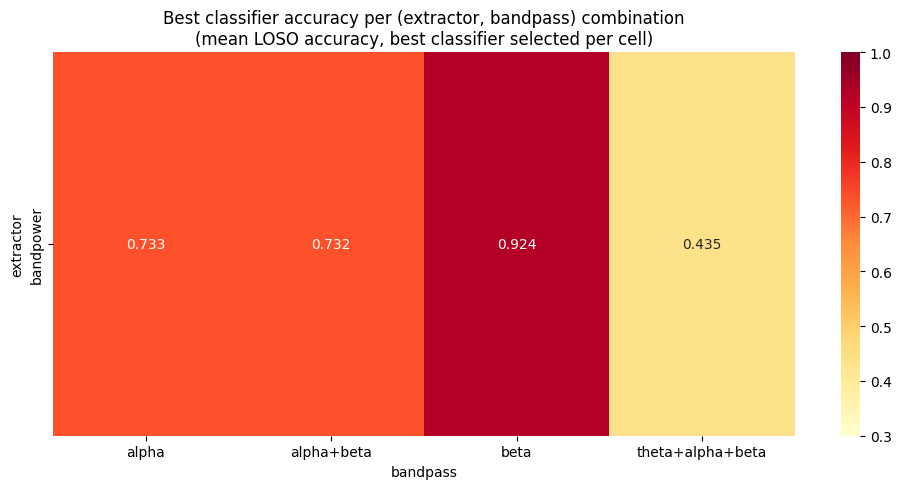

In [ ]:
# =============================================================================
# Heatmap — best classifier per (extractor, bandpass) averaged across folds
# =============================================================================

# For each (extractor, bandpass), find the classifier with the highest mean accuracy
best_per_combo = (
    df.groupby(['extractor', 'bandpass', 'classifier'])['accuracy']
    .mean()
    .reset_index()
    .sort_values('accuracy', ascending=False)
    .groupby(['extractor', 'bandpass'])
    .first()
    .reset_index()
)

heatmap_data = best_per_combo.pivot(index='extractor', columns='bandpass', values='accuracy')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0.3, vmax=1.0)
ax.set_title('Best classifier accuracy per (extractor, bandpass) combination\n(mean LOSO accuracy, best classifier selected per cell)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'heatmap_best_per_combo.png'), dpi=120)
plt.show()

Classifier ranking (averaged across all extractor+bandpass combinations):
              mean    std     max
classifier                       
SVM_linear  0.7063  0.242  0.9788


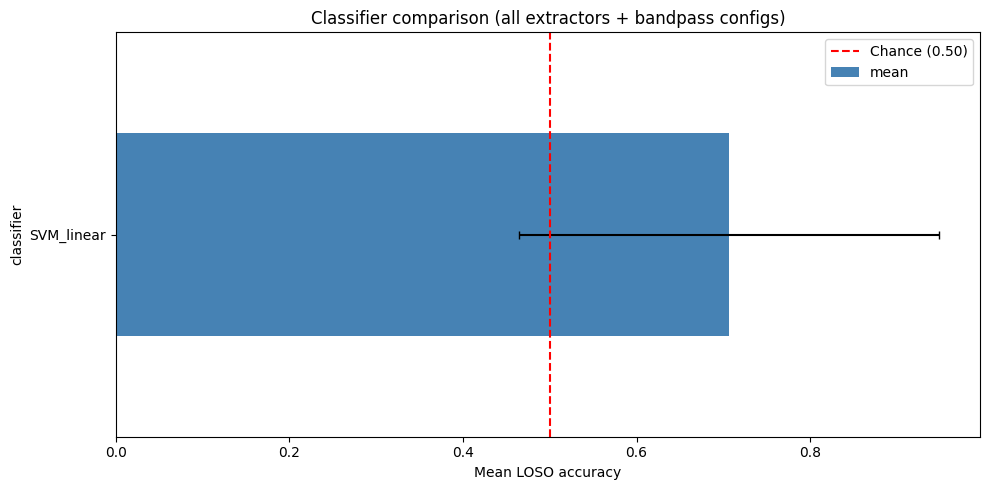

In [ ]:
# =============================================================================
# Classifier comparison — mean accuracy across all extractor/bandpass configs
# =============================================================================

clf_summary = (
    df.groupby('classifier')['accuracy']
    .agg(['mean', 'std', 'max'])
    .round(4)
    .sort_values('mean', ascending=False)
)
print('Classifier ranking (averaged across all extractor+bandpass combinations):')
print(clf_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
clf_summary['mean'].sort_values().plot.barh(xerr=clf_summary['std'].reindex(clf_summary['mean'].sort_values().index), ax=ax, color='steelblue', capsize=3)
ax.set_xlabel('Mean LOSO accuracy')
ax.set_title('Classifier comparison (all extractors + bandpass configs)')
ax.axvline(1/N_CLASSES, color='red', linestyle='--', label=f'Chance ({1/N_CLASSES:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'classifier_comparison.png'), dpi=120)
plt.show()

In [ ]:
# =============================================================================
# Extractor comparison — mean accuracy across all classifier/bandpass configs
# =============================================================================

ext_summary = (
    df.groupby('extractor')['accuracy']
    .agg(['mean', 'std', 'max'])
    .round(4)
    .sort_values('mean', ascending=False)
)
print('Extractor ranking (averaged across all classifier+bandpass combinations):')
print(ext_summary.to_string())

Extractor ranking (averaged across all classifier+bandpass combinations):
             mean    std     max
extractor                       
bandpower  0.7063  0.242  0.9788


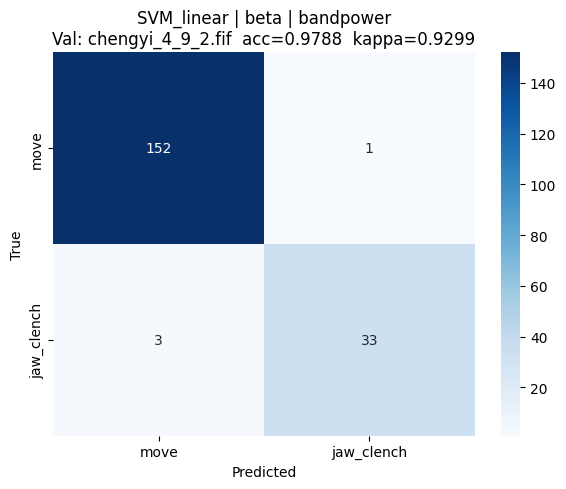


Best: SVM_linear | beta | bandpower
Val session: chengyi_4_9_2.fif
accuracy=0.9788  f1=0.9649  kappa=0.9299


In [ ]:
# =============================================================================
# Confusion matrix — best overall combo
# =============================================================================

best = max([r for r in all_results if r['accuracy'] is not None], key=lambda r: r['accuracy'])
cm   = np.array(best['confusion_matrix'])
class_names = [MAP_LABEL[i] for i in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'{best["classifier"]} | {best["bandpass"]} | {best["extractor"]}\n'
    f'Val: {best["val_session"]}  acc={best["accuracy"]:.4f}  kappa={best["kappa"]:.4f}'
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'best_confusion_matrix.png'), dpi=120)
plt.show()

print(f'\nBest: {best["classifier"]} | {best["bandpass"]} | {best["extractor"]}')
print(f'Val session: {best["val_session"]}')
print(f'accuracy={best["accuracy"]:.4f}  f1={best["f1_macro"]:.4f}  kappa={best["kappa"]:.4f}')

In [ ]:
# BEST IS SVM_LINEAR WITH ALPHA + BETA BANDPOWER for jaw_clenches